# Semana 8 aplicada a diabetes · nivel paciente con historial agregado

**Datos:** `diabetic_data.csv` (130 hospitales de EE. UU., 1999–2008). **Guía:** `semana-08.html` y cuadernos
`sesion_1_gmm`, `sesion_2_kde`, `sesion_3_dbscan`, `refuerzo_kmeans`, `refuerzo_jerarquico`.

**Adaptación del problema.** En el caso original el comité de movilidad busca *zonas del mapa* para un estudio operativo.
Aquí no hay mapa: el "espacio" es un plano de **perfil clínico del paciente** construido con su **historial completo de
encuentros** en la base. El comité (ahora de gestión hospitalaria) desea explorar **perfiles de pacientes candidatos
para un estudio de seguimiento post-alta**. No dispone de costos, capacidad de seguimiento ni desenlaces tras el alta.

> Propongan **dos zonas (perfiles) para estudiar y un perfil para revisar**, o expliquen por qué los datos no bastan.
> Usen GMM, KDE y DBSCAN como tres fuentes de evidencia. No interpreten un centroide como un "paciente tipo" óptimo.

**Diferencia con `semana08_clustering_diabetes.ipynb`.** Ese cuaderno tomaba solo el **primer encuentro** de cada paciente, lo que
descarta el comportamiento longitudinal (quién vuelve y cuántas veces). Aquí cada paciente es **una fila** que **agrega todos sus
encuentros** (número de encuentros, estancia media, medicamentos medios, máximo de visitas previas, etc.): se conserva la historia
sin duplicar filas, así que ningún paciente pesa más en la densidad por hospitalizarse más veces.

Así como densidad de recogidas no es demanda, **densidad de pacientes no es riesgo**: la tasa de readmisión se usa
solo *después* de congelar los modelos, como descripción externa de las zonas, nunca para ajustarlos.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from IPython.display import display
from scipy.special import logsumexp
from scipy.stats import norm
from scipy.integrate import trapezoid
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import silhouette_score

SEED = 42
AX1, AX2 = 'carga clínica total', 'recurrencia (+) vs. intensidad del ingreso (−)'          # nombres de los ejes, fijados tras leer las cargas del PCA (sección 1)
SIGN1, SIGN2 = 'meds_medio', 'n_encuentros'        # variable que define el sentido positivo de cada eje
COLORS = ['#087f8c', '#d57927', '#7856a5', '#c94d61', '#418650', '#b49b24', '#547ba5', '#7a5342']
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'axes.prop_cycle': plt.cycler(color=COLORS)})

# Utilidades equivalentes a movilidad.py, adaptadas a un plano en desviaciones estándar.
def plane_axes(ax, title):
    ax.set(title=title, xlabel=f'CP1 · {AX1} (d.e.)', ylabel=f'CP2 · {AX2} (d.e.)')
    ax.set_aspect('equal', adjustable='box'); ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)

def ellipses(ax, model):
    for k, mean in enumerate(model.means_):
        cov = model.covariances_[k]
        if model.covariance_type == 'diag': cov = np.diag(cov)
        vals, vecs = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
        ax.add_patch(Ellipse(mean, 2*np.sqrt(5.991*vals[-1]), 2*np.sqrt(5.991*vals[0]), angle=angle,
                             facecolor='none', edgecolor=COLORS[k % 8], lw=2))

# Silhouette es O(n²): se calcula sobre una submuestra FIJA (semilla 42) de a lo sumo 1 000 puntos no-ruido.
# Todas las silhouettes del cuaderno son, por tanto, estimaciones sobre 1 000 puntos, no sobre los 6 000.
def safe_silhouette(X, labels, cap=1000):
    labels = np.asarray(labels); mask = labels != -1
    x, lab = X[mask], labels[mask]
    if len(x) < 3 or not 2 <= len(np.unique(lab)) < len(x): return np.nan
    ids = np.random.default_rng(SEED).choice(len(x), min(cap, len(x)), replace=False)
    if not 2 <= len(np.unique(lab[ids])) < len(ids): return np.nan
    return silhouette_score(x[ids], lab[ids])

def grid(size=160):
    gx, gy = np.linspace(*XLIM, size), np.linspace(*YLIM, size)
    xx, yy = np.meshgrid(gx, gy); return gx, gy, xx, yy, np.c_[xx.ravel(), yy.ravel()]

## 0. Contrato experimental (se completa antes de elegir modelos)

| Decisión | Acuerdo |
|---|---|
| **Unidad de análisis y población observada** | **Un paciente**, descrito por el **agregado de todos sus encuentros válidos** en la base (una fila por paciente). Observamos solo pacientes diabéticos *hospitalizados* 1–14 días en 130 hospitales que reportan a esta base, y solo los encuentros que ocurren **dentro de la ventana de la base** (1999–2008); no representa a todos los diabéticos ni a la atención ambulatoria. |
| **Dos variables del plano y sus unidades** | CP1 y CP2 del análisis de componentes principales sobre **10 variables agregadas por paciente** (sección 1), transformadas con `log1p` y estandarizadas **con desarrollo**. Ambos ejes están en **desviaciones estándar** (d.e.), la misma unidad, así que la distancia euclídea es comparable en los dos ejes (análogo a proyectar a km en lugar de usar grados). |
| **Periodo de selección y periodo reservado** | No hay fecha; `encounter_id` es cronológico. Los pacientes se ordenan por su **primer** `encounter_id`. **Desarrollo:** primer 70 % (muestra de 6 000, semilla 42). **Test reservado:** último 30 %. Ningún paciente está en ambos conjuntos. **Advertencia de censura:** los pacientes que aparecen más tarde tienen menos tiempo dentro de la base para acumular encuentros, así que se espera que el test tenga, en promedio, menos encuentros por paciente. Toda elección (K, h, eps) se hace con desarrollo; el test se abre una sola vez al final. |
| **Limpieza vs. recorte** | *Limpieza* = quitar **encuentros** no válidos para la pregunta antes de agregar: género inválido y encuentros cuyo alta fue fallecimiento u hospicio (tras ellos no hay seguimiento posible). Los encuentros repetidos **no** se eliminan: se agregan. *Recorte* = limitar el plano a una región; **no recortamos**: los valores extremos (p. ej. 20+ visitas previas) son pacientes reales, no errores. Los límites de las figuras son solo de visualización. |
| **Qué sería una recomendación útil** | Rangos del plano (y su traducción a variables clínicas) que definan grupos de pacientes suficientemente numerosos y estables en el periodo reservado como para diseñar un estudio de seguimiento. |
| **Qué falta para operar** | Costo y capacidad del seguimiento, desenlaces tras el alta, factores sociales, efecto causal de una intervención. La readmisión observada es una etiqueta incompleta (solo readmisiones en la misma red). **Además, a nivel paciente la readmisión deja de ser una descripción externa independiente:** una readmisión *es* otro encuentro, así que el número de encuentros —un eje del plano— ya la contiene en parte (circularidad; ver sección 1.1). |

## 1. ¿Qué hay detrás del plano? Auditoría y representación
La auditoría aplica reglas **secuenciales**: cada fila del original cae en exactamente un motivo y los motivos suman el total.

In [2]:
raw = pd.read_csv('diabetic_data.csv', na_values=['?'], keep_default_na=False, low_memory=False)
dead_or_hospice = [11, 13, 14, 19, 20, 21]
raw = raw.sort_values('encounter_id').reset_index(drop=True)
motivo = np.select([raw.gender.eq('Unknown/Invalid'), raw.discharge_disposition_id.isin(dead_or_hospice)],
                   ['genero_invalido', 'fallecido_u_hospicio'], default='apto')
auditoria = pd.Series(motivo).value_counts().rename_axis('motivo').reset_index(name='n')
auditoria['porcentaje'] = (100 * auditoria.n / len(raw)).round(3)
display(auditoria); assert auditoria.n.sum() == len(raw)

enc = raw[motivo == 'apto'].copy()
enc['age_num'] = enc.age.str.extract(r'\[(\d+)-').astype(int)[0] + 5
enc['readm30'] = (enc.readmitted == '<30').astype(int)

# Agregación: una fila por paciente con TODOS sus encuentros válidos (sort=False conserva el orden cronológico).
g = enc.groupby('patient_nbr', sort=False)
patients = pd.DataFrame({
    'first_encounter': g.encounter_id.min(),
    'n_encuentros':    g.size(),                          # comportamiento longitudinal dentro de la base
    'estancia_media':  g.time_in_hospital.mean(),         # días por ingreso
    'lab_medio':       g.num_lab_procedures.mean(),
    'proc_medio':      g.num_procedures.mean(),
    'meds_medio':      g.num_medications.mean(),
    'diag_medio':      g.number_diagnoses.mean(),
    'ambulat_max':     g.number_outpatient.max(),         # máximo de visitas en el año previo a algún ingreso
    'urgenc_max':      g.number_emergency.max(),
    'hosp_prev_max':   g.number_inpatient.max(),
    'edad':            g.age_num.first(),                 # edad en el primer ingreso
    'readm30_alguna':  g.readm30.max(),                   # descripción externa (ver circularidad)
    'readm30_primero': g.readm30.first(),
}).sort_values('first_encounter')
FEATURES = ['n_encuentros', 'estancia_media', 'lab_medio', 'proc_medio', 'meds_medio', 'diag_medio',
            'ambulat_max', 'urgenc_max', 'hosp_prev_max', 'edad']
assert patients.index.is_unique and len(patients) == enc.patient_nbr.nunique()
print(f'Encuentros aptos: {len(enc):,} → pacientes: {len(patients):,} (una fila por paciente)')
display(patients.n_encuentros.value_counts().sort_index().head(8).rename('pacientes').to_frame().T)

cut = int(len(patients) * 0.7)
dev_pool, test = patients.iloc[:cut], patients.iloc[cut:].copy()
dev = dev_pool.sample(6000, random_state=SEED).sort_values('first_encounter').copy()
assert dev.first_encounter.max() < test.first_encounter.min() and not set(dev.index) & set(test.index)
print(f'Pool de desarrollo: {len(dev_pool):,} | muestra de desarrollo: {len(dev):,} | test reservado: {len(test):,}')

,motivo,n,porcentaje
0,apto,99340,97.616
1,fallecido_u_hospicio,2423,2.381
2,genero_invalido,3,0.003


Encuentros aptos: 99,340 → pacientes: 69,987 (una fila por paciente)


n_encuentros,1,2,3,4,5,6,7,8
pacientes,53646,10218,3233,1354,691,338,192,112


Pool de desarrollo: 48,990 | muestra de desarrollo: 6,000 | test reservado: 20,997


### 1.1 Dos advertencias antes de modelar: censura y circularidad

In [3]:
cmp = pd.DataFrame({
    'desarrollo (pool)': [dev_pool.n_encuentros.mean(), (dev_pool.n_encuentros > 1).mean(), dev_pool.readm30_alguna.mean(), dev_pool.readm30_primero.mean()],
    'test':              [test.n_encuentros.mean(), (test.n_encuentros > 1).mean(), test.readm30_alguna.mean(), test.readm30_primero.mean()]},
    index=['encuentros por paciente', '% con más de un encuentro', 'readmisión <30 en algún encuentro', 'readmisión <30 en el primer encuentro'])
display(cmp.round(3))
circ = patients.groupby(patients.n_encuentros.clip(upper=4)).agg(pacientes=('edad', 'size'),
        readm30_alguna=('readm30_alguna', 'mean'), readm30_primero=('readm30_primero', 'mean'))
circ.index = ['1', '2', '3', '4+']; circ.index.name = 'n_encuentros'
display(circ.round(3))

,desarrollo (pool),test
encuentros por paciente,1.477,1.285
% con más de un encuentro,0.252,0.189
readmisión <30 en algún encuentro,0.136,0.101
readmisión <30 en el primer encuentro,0.097,0.072


,pacientes,readm30_alguna,readm30_primero
n_encuentros,,,
1,53646,0.043,0.043
2,10218,0.287,0.241
3,3233,0.470,0.247
4+,2890,0.714,0.256


**Nuestra respuesta y evidencia:**


- **Censura:** los pacientes del periodo reservado tienen en promedio **1.29 encuentros** frente a **1.48** en desarrollo, y solo el 18.9 % tiene más de uno
  (25.2 % en desarrollo). No es que sean más sanos: aparecen más tarde y la base termina en 2008, así que tienen menos tiempo para volver. Cualquier
  diferencia de densidad entre desarrollo y test en la zona de recurrencia tendrá este sesgo.
- **Circularidad:** la readmisión < 30 días en *algún* encuentro pasa de **4.3 %** con 1 encuentro a 28.7 % con 2, 47 % con 3 y **71 %** con 4 o más. No es un
  hallazgo: una readmisión registrada *es* otro encuentro. Incluso la readmisión del *primer* encuentro sube de 4.3 % a ~25 % en cuanto hay ≥ 2 encuentros.
  Consecuencia: en este plano, que contiene `n_encuentros`, la readmisión **no sirve como validación externa independiente** de las zonas; solo se usa para
  describirlas, advirtiendo que parte de la asociación está construida.
- El 4.3 % de pacientes con un solo encuentro que sí figuran como readmitidos muestra que hay readmisiones **fuera** de la base (otra red u hospital): el historial agregado también es incompleto.

**Representación.** Las variables agregadas son conteos y promedios de conteos, con colas largas y escalas distintas
(encuentros, días, procedimientos, medicamentos, años). Si se usaran tal cual, la distancia la dominaría `lab_medio`. Por eso: `log1p` → estandarización
**ajustada solo con desarrollo** → PCA a 2 componentes. El escalado aquí sí es necesario (a diferencia de las coordenadas
UTM del caso original, aquí las variables no comparten unidad); lo que evitamos es escalar cada eje del plano final por separado.

Varianza explicada: [0.239 0.178] → total 0.417


,CP1,CP2
n_encuentros,0.420000,0.430000
estancia_media,0.340000,-0.370000
lab_medio,0.190000,-0.190000
proc_medio,0.190000,-0.330000
meds_medio,0.390000,-0.380000
diag_medio,0.370000,-0.210000
ambulat_max,0.240000,0.250000
urgenc_max,0.250000,0.320000
hosp_prev_max,0.430000,0.380000
edad,0.180000,-0.180000


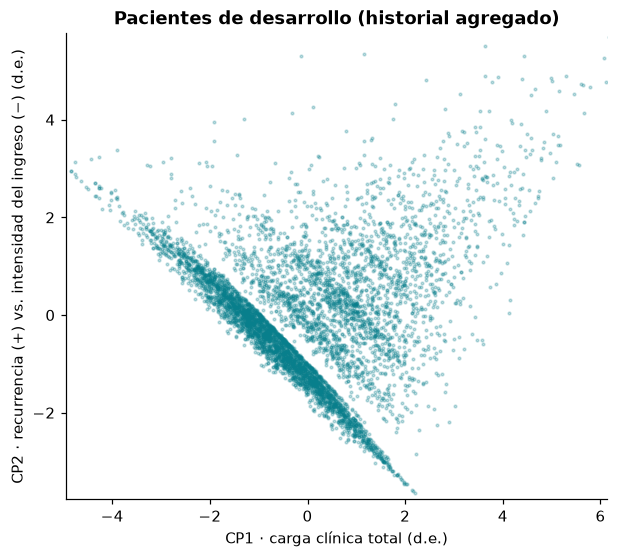

Puntos repetidos exactamente en el plano: 7


In [4]:
scaler = StandardScaler().fit(np.log1p(dev[FEATURES]))
pca = PCA(2, random_state=SEED).fit(scaler.transform(np.log1p(dev[FEATURES])))
if pca.components_[0][FEATURES.index(SIGN1)] < 0: pca.components_[0] *= -1
if pca.components_[1][FEATURES.index(SIGN2)] < 0: pca.components_[1] *= -1
project = lambda f: pca.transform(scaler.transform(np.log1p(f[FEATURES])))
X, Xt = project(dev), project(test)
dev[['cp1', 'cp2']], test[['cp1', 'cp2']] = X, Xt
XLIM = (np.percentile(X[:, 0], .2) - .5, np.percentile(X[:, 0], 99.8) + .5)
YLIM = (np.percentile(X[:, 1], .2) - .5, np.percentile(X[:, 1], 99.8) + .5)

loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=['CP1', 'CP2']).round(2)
print('Varianza explicada:', pca.explained_variance_ratio_.round(3), '→ total', pca.explained_variance_ratio_.sum().round(3))
display(loadings.style.background_gradient(cmap='RdBu_r', vmin=-.7, vmax=.7))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(*X.T, s=3, alpha=.25, color=COLORS[0]); plane_axes(ax, 'Pacientes de desarrollo (historial agregado)')
plt.show()
print('Puntos repetidos exactamente en el plano:', len(X) - len(np.unique(X.round(8), axis=0)))

### Para resolver
Antes de ajustar: ¿cuántos grupos ves? ¿Qué podría significar un punto aislado?

**Nuestra respuesta y evidencia:**


- **Cargas:** CP1 tiene signo positivo en todas las variables (máximas en `hosp_prev_max` 0.43, `n_encuentros` 0.42, `meds_medio` 0.39, `diag_medio` 0.37):
  es la **carga clínica total** del paciente. CP2 opone la **recurrencia** (`n_encuentros` 0.43, `hosp_prev_max` 0.38, `urgenc_max` 0.32, `ambulat_max` 0.25) a la
  **intensidad de cada ingreso** (`meds_medio` −0.38, `estancia_media` −0.37, `proc_medio` −0.33). Los dos ejes explican el 42 % de la varianza (37 % en el cuaderno de primer encuentro).
- **Qué se ve:** una **cresta diagonal muy densa** que baja de izquierda arriba a derecha abajo y un **abanico** disperso por encima y a la derecha. La cresta son
  los pacientes con **un solo encuentro** y sin visitas previas (74.6 % de la muestra): como para ellos `n_encuentros` = 1 y las visitas previas son 0, solo varían en
  intensidad, que mueve el punto en diagonal. El abanico son los pacientes **recurrentes**.
- **Dos particiones plausibles:** (a) cresta vs. abanico (un encuentro vs. varios); (b) cortar además la cresta por intensidad (ingresos breves arriba a la izquierda,
  largos abajo a la derecha).
- **Un punto aislado** arriba a la derecha es un paciente con muchos encuentros y muchas visitas previas; es real, no un error.

## 2. GMM · De Bayes a EM (Sesión 1)
$$r_{ik}=\frac{\pi_k\phi(x_i;\mu_k,\Sigma_k)}{\sum_j\pi_j\phi(x_i;\mu_j,\Sigma_j)},\quad N_k=\sum_i r_{ik},\quad
\pi_k^{+}=\frac{N_k}{n},\quad \mu_k^{+}=\frac{\sum_i r_{ik}x_i}{N_k},\quad \Sigma_k^{+}=\frac{\sum_i r_{ik}(x_i-\mu_k^{+})(x_i-\mu_k^{+})^T}{N_k}.$$

### Para resolver (iteración manual)
$x=(-2,-1,1,2)$, pesos $(0.5,0.5)$, medias $(-1,1)$, varianzas $(1,1)$.

In [5]:
x = np.array([-2., -1., 1., 2.])
weights, means, variances = np.array([.5, .5]), np.array([-1., 1.]), np.ones(2)
history, first = [], None
for it in range(12):
    log_joint = np.log(weights)[None, :] + norm.logpdf(x[:, None], means, np.sqrt(variances))
    history.append(float(logsumexp(log_joint, axis=1).sum()))
    resp = np.exp(log_joint - logsumexp(log_joint, axis=1, keepdims=True))
    nk = resp.sum(0); weights = nk / len(x)
    means = (resp * x[:, None]).sum(0) / nk
    variances = (resp * (x[:, None] - means) ** 2).sum(0) / nk
    if it == 0: first = (resp.round(4), weights.round(4), means.round(4), variances.round(4))
assert np.all(np.diff(history) >= -1e-9)
for name, v in zip(['responsabilidades (filas = x)', 'pesos', 'medias', 'varianzas'], first): print(name, '\n', v)
print('log-verosimilitud por iteración:', np.round(history[:5], 4), '...')

responsabilidades (filas = x) 
 [[0.982  0.018 ]
 [0.8808 0.1192]
 [0.1192 0.8808]
 [0.018  0.982 ]]
pesos 
 [0.5 0.5]
medias 
 [-1.3448  1.3448]
varianzas 
 [0.6914 0.6914]
log-verosimilitud por iteración: [-7.1582 -6.4619 -5.7243 -5.6757 -5.6757] ...


**Nuestra respuesta y evidencia:**


**E-step:** para $x=-2$: $r_{1}=\frac{e^{-0.5}}{e^{-0.5}+e^{-4.5}}=\frac{1}{1+e^{-4}}=0.982$; para $x=-1$: $\frac{1}{1+e^{-2}}=0.881$;
por simetría $x=1\to0.119$ y $x=2\to0.018$.
**M-step:** $N_1=N_2=2.0$ → pesos $(0.5,0.5)$; $\mu_1=\frac{-2(0.982)-1(0.881)+1(0.119)+2(0.018)}{2}=-1.345$, $\mu_2=1.345$;
$\sigma_1^2=\sigma_2^2=0.691$ (calculada con la **media nueva**). La log-verosimilitud sube de −7.158 a −6.462 y se estabiliza en −5.676:
EM mejora localmente; las medias se separan y las varianzas se reducen porque los datos están más alejados que las medias iniciales.

### 2.1 Elegir complejidad sin abrir test
$\mathrm{BIC}=-2\ell(\hat\theta)+p\log n$. Para covarianza completa $p=(K-1)+Kd+Kd(d+1)/2$. Se compara BIC solo sobre las mismas 6 000 observaciones.

,k,covariance,bic,aic,converged,iterations
7,8,full,33497.5,33182.6,True,31
6,7,full,33571.2,33296.5,True,28
5,6,full,33588.0,33353.5,True,21
8,9,full,33756.9,33401.8,True,15
9,10,full,33795.5,33400.2,True,13
4,5,full,33831.8,33637.5,True,19
3,4,full,33918.8,33764.7,True,15
2,3,full,34167.4,34053.5,True,13


Ganador BIC: {'k': 8, 'covariance': 'full'}


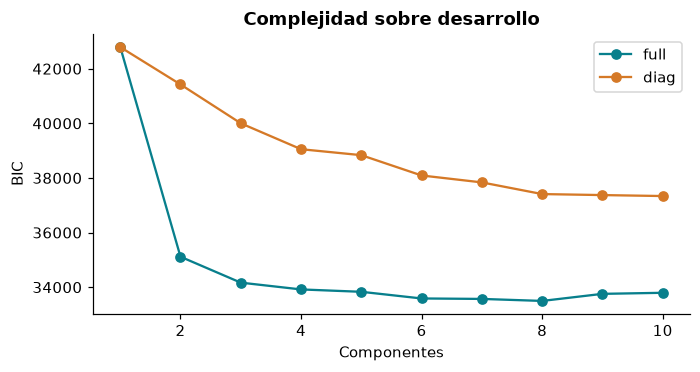

In [6]:
models, rows = {}, []
for cov in ['full', 'diag']:
    for k in range(1, 11):
        m = GaussianMixture(k, covariance_type=cov, n_init=5, max_iter=400, reg_covar=1e-5, random_state=SEED).fit(X)
        rows.append(dict(k=k, covariance=cov, bic=m.bic(X), aic=m.aic(X), converged=bool(m.converged_), iterations=m.n_iter_))
        models[(k, cov)] = m
gmm_sel = pd.DataFrame(rows)
display(gmm_sel.sort_values('bic').head(8).round(1))
winner = gmm_sel[gmm_sel.converged].sort_values('bic').iloc[0]
best = models[(int(winner.k), winner.covariance)]
print('Ganador BIC:', dict(k=int(winner.k), covariance=winner.covariance))
fig, ax = plt.subplots(figsize=(7, 3.3))
for cov in ['full', 'diag']:
    part = gmm_sel[gmm_sel.covariance == cov]; ax.plot(part.k, part.bic, 'o-', label=cov)
ax.set(xlabel='Componentes', ylabel='BIC', title='Complejidad sobre desarrollo'); ax.legend(); plt.show()

### Para resolver
Si el mínimo ocurre en el borde de la rejilla, ¿qué puede concluir? ¿Se justifica anunciar K perfiles verdaderos?

**Nuestra respuesta y evidencia:**


Con covarianza completa el mínimo está en **K = 8** (rejilla 1–10, interior); con covarianza diagonal el BIC sigue bajando hasta **K = 10, el borde** de la rejilla:
con elipses alineadas a los ejes no alcanza para describir una cresta diagonal. Ninguno de los dos números es "el número de perfiles". La densidad tiene una forma
muy no gaussiana (una cresta estrecha con un borde duro, producido por `n_encuentros` ≥ 1 y visitas ≥ 0), y el GMM la aproxima **pegando varias elipses alargadas**
a lo largo de la cresta (componentes 2, 5, 6 y 0 en la figura). La componente 3 tiene solo 17 pacientes (0.3 %): es una pieza para ajustar la punta de la cresta, no un grupo.

### 2.2 Figura 1 · Componentes, contornos del 95 % y entropía de pertenencia

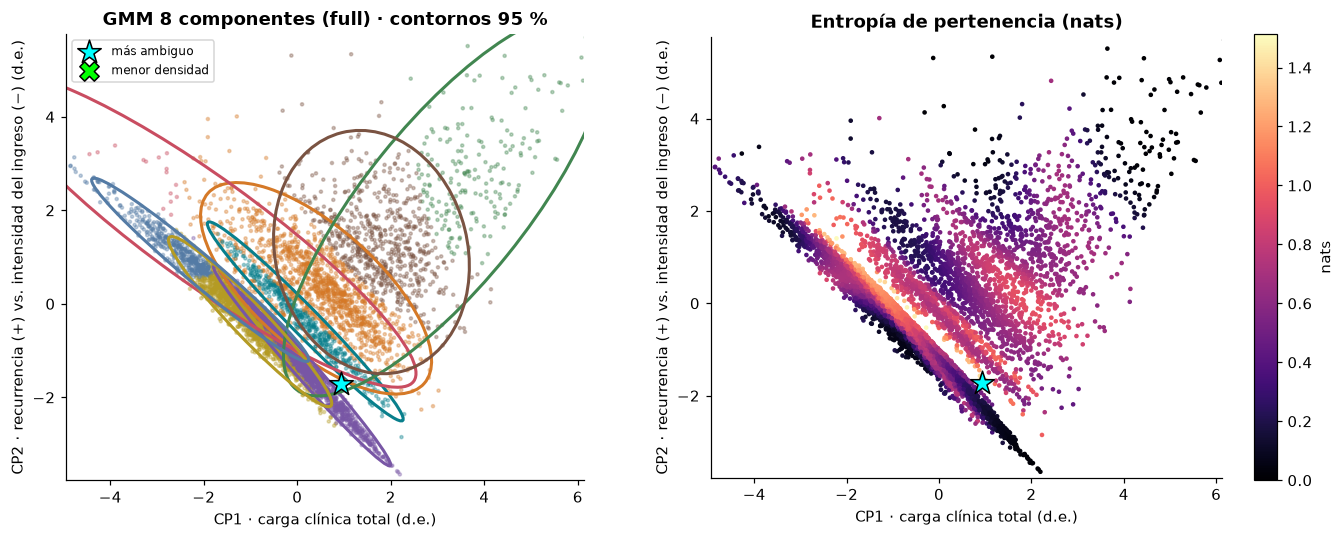

,peso,media_cp1,media_cp2
0,0.055,0.17,-0.38
1,0.210,0.40,0.33
2,0.221,0.10,-1.33
3,0.008,-1.99,1.58
4,0.052,3.16,2.12
5,0.229,-1.01,-0.38
6,0.107,-2.08,0.73
7,0.119,1.59,1.11


Proporción asignada (asignación dura): [0.07       0.219      0.252      0.00283333 0.03416667 0.2325
 0.07816667 0.11133333]
Punto más ambiguo:  responsabilidades [0.034 0.479 0.029 0.006 0.112 0.03  0.208 0.101] | log-densidad -5.69 | percentil de densidad 0.035
Punto de menor densidad: máx. responsabilidad 1.0 | log-densidad -13.82


,n_encuentros,estancia_media,lab_medio,proc_medio,meds_medio,diag_medio,ambulat_max,urgenc_max,hosp_prev_max,edad,cp1,cp2
ambiguo,1,5.0,75.00,6.00,28.00,6.0,1,0,0,65,0.93,-1.72
baja densidad,23,6.3,46.65,1.13,13.43,8.7,6,11,12,45,8.84,8.50


In [7]:
resp = best.predict_proba(X)
entropy = -(resp * np.log(np.maximum(resp, 1e-300))).sum(1)
logdens_gmm = best.score_samples(X)
i_amb, i_low = int(np.argmax(entropy)), int(np.argmin(logdens_gmm))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(*X.T, c=np.asarray(COLORS)[best.predict(X) % 8], s=4, alpha=.35); ellipses(axes[0], best)
pts = axes[1].scatter(*X.T, c=entropy, cmap='magma', s=4)
for ax, t in zip(axes, [f'GMM {int(winner.k)} componentes ({winner.covariance}) · contornos 95 %', 'Entropía de pertenencia (nats)']):
    plane_axes(ax, t)
    ax.scatter(*X[i_amb], marker='*', s=260, c='cyan', edgecolor='k', label='más ambiguo')
    ax.scatter(*X[i_low], marker='X', s=160, c='lime', edgecolor='k', label='menor densidad')
axes[0].legend(loc='upper left', fontsize=8); fig.colorbar(pts, ax=axes[1], label='nats'); fig.tight_layout(); plt.show()

comp = pd.DataFrame({'peso': best.weights_.round(3), 'media_cp1': best.means_[:, 0].round(2), 'media_cp2': best.means_[:, 1].round(2)})
display(comp)
print('Proporción asignada (asignación dura):', np.bincount(best.predict(X), minlength=int(winner.k)) / len(X))
cols = FEATURES + ['cp1', 'cp2']
print('Punto más ambiguo:  responsabilidades', resp[i_amb].round(3), '| log-densidad', logdens_gmm[i_amb].round(2),
      '| percentil de densidad', (logdens_gmm < logdens_gmm[i_amb]).mean().round(3))
print('Punto de menor densidad: máx. responsabilidad', resp[i_low].max().round(3), '| log-densidad', logdens_gmm[i_low].round(2))
display(dev.iloc[[i_amb, i_low]][cols].set_axis(['ambiguo', 'baja densidad']).round(2))

### Para resolver
Elijan un punto de pertenencia ambigua y otro de densidad baja. ¿Son necesariamente el mismo?

**Nuestra respuesta y evidencia:**


- **Punto ambiguo** (CP1 = 0.93, CP2 = −1.72): responsabilidades máximas de 0.48 y 0.21. Es un paciente de un solo encuentro con un ingreso muy intenso
  (28 medicamentos, 75 análisis, 6 procedimientos), en el borde donde la cresta se ensancha. Su log-densidad está en el **percentil 3.5**: aquí, a diferencia del
  cuaderno de primer encuentro, el punto más ambiguo **también** es poco denso, porque queda entre la cresta y el abanico, donde ninguna elipse lo cubre bien.
- **Punto de menor densidad** (CP1 = 8.8, CP2 = 8.5, fuera de la figura): **23 encuentros**, 12 hospitalizaciones y 11 urgencias previas; responsabilidad 1.0 para una componente.
- **No son el mismo punto** y no tienen por qué serlo: la responsabilidad compara componentes entre sí; la densidad mide qué tan común es el paciente. Que en este
  plano el ambiguo sea además poco denso es una propiedad de esta geometría, no una regla.

### 2.3 ¿Qué representa cada componente?

**Nuestra respuesta y evidencia:**


Medianas de los pacientes asignados a cada componente (tabla completa en 6.2); la readmisión se calculó después de congelar el modelo y es **circular** con `n_encuentros` (sección 1.1).

| Comp. | Asignados | Qué representa | % con > 1 encuentro | Readmisión < 30 d en algún encuentro (desarrollo / test) |
|---|---|---|---|---|
| **2** | 25 % | Cresta, ingresos **largos y complejos**, un solo encuentro: 5 días, 18 medicamentos, 9 diagnósticos, 75 años | 0 % | 5.5 % / 2.6 % |
| **5** | 23 % | Cresta, ingresos **moderados**, un solo encuentro: 3 días, 12 medicamentos, 5 diagnósticos | 0 % | 2.8 % / 1.9 % |
| **1** | 22 % | **Transición**: la mitad ya tiene más de un encuentro; 1 hospitalización previa (mediana) | 49 % | 19.9 % / 16.5 % |
| **7** | 11 % | **Recurrentes**: 3 encuentros, 2 hospitalizaciones previas (medianas) | 87 % | 42.8 % / 37.5 % |
| **6** | 8 % | Cresta, ingresos **breves y simples**: 2 días, 6 medicamentos, 55 años | 0 % | 0.9 % / 0.8 % |
| **0** | 7 % | Borde inferior del abanico, pocos con historial | 24 % | 7.4 % / 3.8 % |
| **4** | 3 % | **Muy recurrentes**: 5 encuentros, 3 hospitalizaciones, 1 urgencia y 1 consulta previas | 99 % | 69.3 % / 62.9 % |
| **3** | 0.3 % | Punta de la cresta (17 pacientes jóvenes de ingreso mínimo): pieza técnica del ajuste | 6 % | 0 % / 1.6 % |

Las cuatro componentes de la cresta (2, 5, 6, 3) tienen readmisión muy baja porque sus pacientes, por construcción, no volvieron *dentro de la base*.

## 3. KDE · Del punto a una superficie (Sesión 2)
$\hat f_h(x)=\frac{1}{nh^d}\sum_i K\left(\frac{x-x_i}{h}\right)$. En este plano la densidad está en **d.e.$^{-2}$**; su integral sobre una región es una proporción de pacientes.

### Para resolver
Con $x=(-1,0,1)$ y kernel gaussiano, calcule $\hat f_h(0)$ para $h=0.5,1,2$. ¿Debe decrecer siempre la altura al aumentar h?

In [8]:
for h in [.5, 1, 2]:
    manual = np.mean(norm.pdf((0 - np.array([-1, 0, 1])) / h)) / h
    sk = np.exp(KernelDensity(bandwidth=h).fit(np.array([[-1.], [0.], [1.]])).score_samples([[0.]]))[0]
    print(f'h={h}: f(0) manual={manual:.4f} | sklearn={sk:.4f}')
    assert np.isclose(manual, sk)
# Contraejemplo: en un punto alejado de los datos la altura CRECE con h.
for h in [.5, 1, 2]:
    print(f'h={h}: f(4) = {np.mean(norm.pdf((4 - np.array([-1, 0, 1])) / h)) / h:.5f}')

h=0.5: f(0) manual=0.3379 | sklearn=0.3379
h=1: f(0) manual=0.2943 | sklearn=0.2943
h=2: f(0) manual=0.1838 | sklearn=0.1838
h=0.5: f(4) = 0.00000
h=1: f(4) = 0.00152
h=2: f(4) = 0.03351


**Nuestra respuesta y evidencia:**


$\hat f_h(0)=\frac{1}{3h}\left[\phi(1/h)+\phi(0)+\phi(1/h)\right]$: **0.338** (h = 0.5), **0.294** (h = 1), **0.184** (h = 2) — coinciden con scikit-learn.
En 0 decrece, pero **no siempre**: en $x=4$, lejos de los datos, la altura *crece* con h (0.000 → 0.0015 → 0.034), porque un kernel más
ancho reparte masa hacia las zonas vacías. Aumentar h reduce varianza y aumenta sesgo; no mueve la densidad en una sola dirección.

### 3.1 Elegir h con validación temporal dentro de desarrollo
Tres particiones expansivas en orden del primer `encounter_id` de cada paciente: cada KDE se ajusta con el pasado del fold y se evalúa en el bloque siguiente
con la **log-densidad media por observación** (comparable entre folds de distinto tamaño).

,h,mean,std
0,0.05,-4.1637,0.7975
1,0.10,-3.0769,0.2596
2,0.20,-2.9530,0.1495
3,0.30,-3.0285,0.1235
4,0.40,-3.1049,0.1093
5,0.60,-3.2350,0.0918
6,0.80,-3.3437,0.0803
7,1.60,-3.7386,0.0497


Ancho congelado (d.e.): 0.2


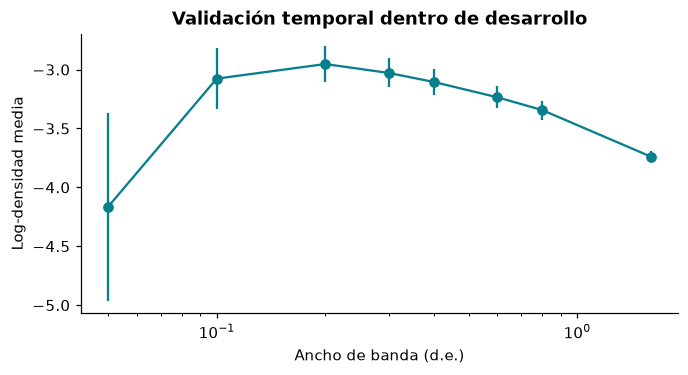

In [9]:
bandwidths = [.05, .1, .2, .3, .4, .6, .8, 1.6]
folds = list(TimeSeriesSplit(n_splits=3).split(X))
rows = []
for h in bandwidths:
    for f, (tr, va) in enumerate(folds, 1):
        assert dev.first_encounter.iloc[tr].max() < dev.first_encounter.iloc[va].min()
        rows.append(dict(h=h, fold=f, mean_log_density=KernelDensity(bandwidth=h).fit(X[tr]).score_samples(X[va]).mean()))
kde_cv = pd.DataFrame(rows).groupby('h').mean_log_density.agg(['mean', 'std']).reset_index()
display(kde_cv.round(4))
best_h = float(kde_cv.loc[kde_cv['mean'].idxmax(), 'h'])
kde = KernelDensity(bandwidth=best_h).fit(X)
print('Ancho congelado (d.e.):', best_h)
fig, ax = plt.subplots(figsize=(7, 3.3))
ax.errorbar(kde_cv.h, kde_cv['mean'], yerr=kde_cv['std'], fmt='o-'); ax.set_xscale('log')
ax.set(xlabel='Ancho de banda (d.e.)', ylabel='Log-densidad media', title='Validación temporal dentro de desarrollo'); plt.show()

### Para resolver
¿Por qué no comparar `score(X)` de modelos con distinto n sin normalizar? ¿Por qué no usar la altura del pico para elegir h?

**Nuestra respuesta y evidencia:**


Se eligió **h = 0.2 d.e.** (log-densidad media −2.953 en validación; h = 0.1 da −3.08 y h = 0.3 −3.03). Es la mitad que en el cuaderno de primer encuentro (0.4):
la cresta de pacientes de un solo encuentro es muy estrecha y un kernel ancho la "derramaría".
- `score(X)` es una **suma**: crece con n; comparar sin dividir por n compara tamaños, no calidad. Por eso se usa la media por observación.
- La **altura del pico** siempre crece al reducir h; elegirla premia el sobreajuste. Lo que importa es predecir la densidad de pacientes que aparecen después.

### 3.2 Figura 2 · Superficie KDE con tres anchos (misma escala de color y mismos ejes)

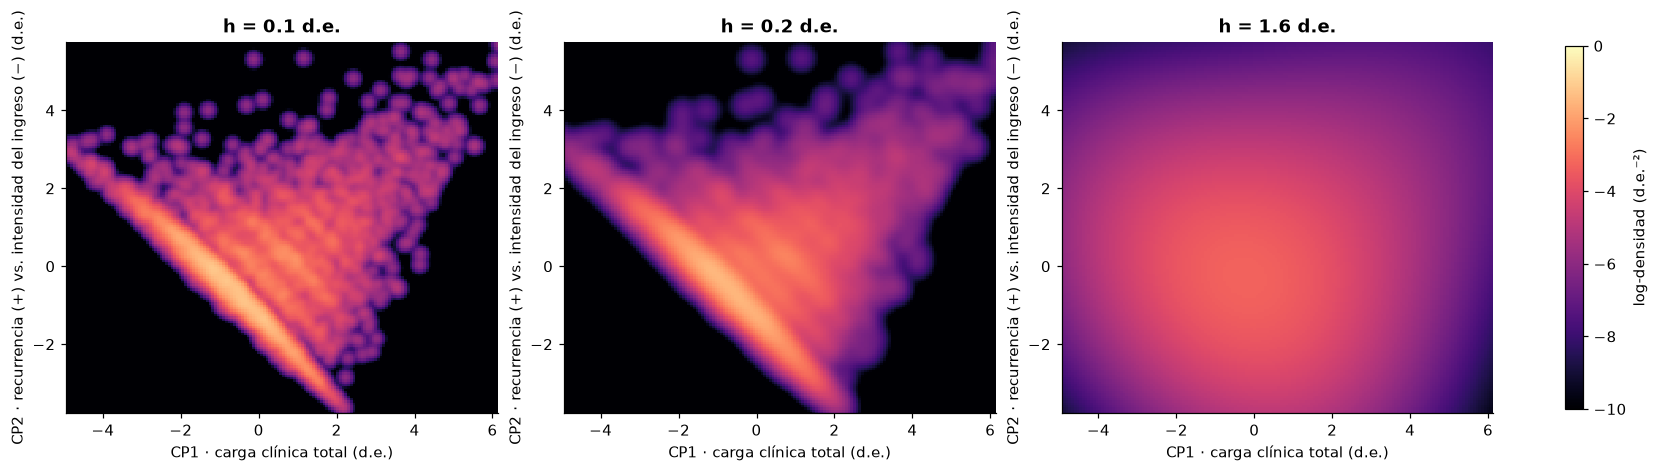

Masa total en la ventana: 0.998. Región de mayor densidad que contiene el 50 % de la masa: 4.3% del área de la ventana.


In [10]:
gx, gy, xx, yy, G = grid()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), layout='constrained')
for ax, h in zip(axes, [.1, best_h, 1.6]):
    ld = KernelDensity(bandwidth=h).fit(X).score_samples(G).reshape(xx.shape)
    mesh = ax.pcolormesh(xx, yy, ld, shading='auto', cmap='magma', vmin=-10, vmax=0)
    plane_axes(ax, f'h = {h:g} d.e.')
fig.colorbar(mesh, ax=list(axes), label='log-densidad (d.e.⁻²)', shrink=.7); plt.show()

dens = np.exp(kde.score_samples(G)).reshape(xx.shape)
dx, dy = gx[1] - gx[0], gy[1] - gy[0]
order = np.sort(dens.ravel())[::-1]; cum = np.cumsum(order) * dx * dy
level50 = order[np.searchsorted(cum, .5)]
print(f'Masa total en la ventana: {cum[-1]:.3f}. Región de mayor densidad que contiene el 50 % de la masa: '
      f'{(dens >= level50).mean():.1%} del área de la ventana.')

### 3.3 Masa en una región fija

In [11]:
def kde_mass(x0, x1, y0, y1, n=200):
    rx, ry = np.linspace(x0, x1, n), np.linspace(y0, y1, n); rxx, ryy = np.meshgrid(rx, ry)
    v = np.exp(kde.score_samples(np.c_[rxx.ravel(), ryy.ravel()])).reshape(rxx.shape)
    return trapezoid(trapezoid(v, rx, axis=1), ry)
region = (-1, 1, -1, 1)
m = kde_mass(*region)
emp = np.mean((X[:, 0] >= -1) & (X[:, 0] <= 1) & (X[:, 1] >= -1) & (X[:, 1] <= 1))
print(f'Masa KDE en CP1∈[-1,1] × CP2∈[-1,1]: {m:.3f} | fracción empírica de pacientes: {emp:.3f}')

Masa KDE en CP1∈[-1,1] × CP2∈[-1,1]: 0.283 | fracción empírica de pacientes: 0.290


### Para resolver
Ticket: explique por qué densidad puntual, masa en una región y número de camas/enfermeras de seguimiento son tres cantidades diferentes.

**Nuestra respuesta y evidencia:**


- **Densidad puntual** (d.e.⁻²): altura de la superficie; puede superar 1.
- **Masa regional**: integral sobre un área, es una proporción de pacientes. En CP1, CP2 ∈ [−1, 1] la KDE da **0.283** y la fracción empírica es 0.290.
- **Recursos de seguimiento**: dependen del número absoluto de pacientes, del riesgo y de la capacidad; además, aquí un paciente del abanico **consume varios
  ingresos**, así que la carga asistencial de una zona no es su masa de pacientes sino esa masa multiplicada por sus encuentros.

## 4. DBSCAN · Zonas conectadas y puntos aislados (Sesión 3)
$N_\varepsilon(x_i)=\{x_j:\|x_i-x_j\|\le\varepsilon\}$; núcleo si $|N_\varepsilon(x_i)|\ge m$ contándose a sí mismo.

### Para resolver
En una línea: A=0, B=0.1, C=0.2, D=0.3, E=0.8. eps=0.115, min_samples=3.

In [12]:
tiny = np.c_[[0, .1, .2, .3, .8], np.zeros(5)]
manual = DBSCAN(eps=.115, min_samples=3).fit(tiny)
nbrs = NearestNeighbors(radius=.115).fit(tiny).radius_neighbors(tiny, return_distance=False)
print('Vecinos:', {'ABCDE'[i]: ['ABCDE'[j] for j in sorted(v)] for i, v in enumerate(nbrs)})
print('Núcleos:', ['ABCDE'[i] for i in manual.core_sample_indices_], '| etiquetas:', manual.labels_)

Vecinos: {'A': ['A', 'B'], 'B': ['A', 'B', 'C'], 'C': ['B', 'C', 'D'], 'D': ['C', 'D'], 'E': ['E']}
Núcleos: ['B', 'C'] | etiquetas: [ 0  0  0  0 -1]


**Nuestra respuesta y evidencia:**


Vecinos con eps = 0.115 (incluyéndose): A={A,B}, B={A,B,C}, C={B,C,D}, D={C,D}, E={E}.
**Núcleos:** B y C (3 vecinos ≥ m = 3). **Fronteras:** A y D (alcanzables desde un núcleo, pero con solo 2 vecinos no expanden).
**Ruido:** E (0.5 de distancia al más cercano). Resultado: un grupo {A,B,C,D} y E como ruido. El diámetro del grupo (0.3) **supera** eps:
la conectividad encadena núcleos.

### 4.1 Distancia al m-ésimo vecino y tabla de sensibilidad (desarrollo)
La tabla reporta, para cada configuración, **número de grupos, cobertura** (fracción de puntos que no son ruido), el tamaño del mayor grupo
y del segundo, y la **silhouette**. Importante: la silhouette **excluye el ruido** y se calcula sobre una **submuestra fija de 1 000 puntos**
(semilla 42) de los no-ruido, porque su costo es cuadrático; no es la silhouette de los 6 000 pacientes. Cuando hay menos de 2 grupos no está definida (NaN).

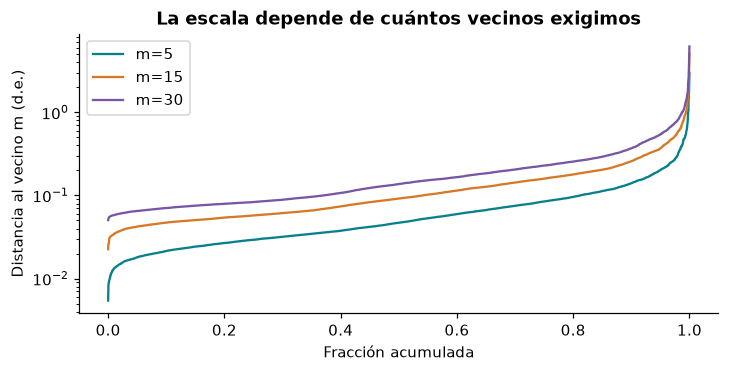

,eps,min_samples,n_clusters,coverage,largest_share,second_cluster,silhouette_1000
0,0.1,5,41,0.872,0.548,1561,-0.253
1,0.1,15,14,0.632,0.517,216,-0.223
2,0.1,30,1,0.458,0.458,0,NaN
3,0.2,5,11,0.965,0.952,16,0.145
4,0.2,15,2,0.897,0.890,42,0.154
5,0.2,30,5,0.792,0.554,1245,0.147
6,0.3,5,2,0.985,0.982,17,0.581
7,0.3,15,2,0.947,0.944,15,NaN
8,0.3,30,1,0.903,0.903,0,NaN
9,0.4,5,2,0.992,0.990,12,0.652


In [13]:
fig, ax = plt.subplots(figsize=(7.5, 3.3))
for m in [5, 15, 30]:
    d_, _ = NearestNeighbors(n_neighbors=m).fit(X).kneighbors(X)
    kth = np.sort(d_[:, m - 1]); ax.plot(np.arange(len(kth)) / len(kth), kth, label=f'm={m}')
ax.set(xlabel='Fracción acumulada', ylabel='Distancia al vecino m (d.e.)', yscale='log',
       title='La escala depende de cuántos vecinos exigimos'); ax.legend(); plt.show()

rows = []
for eps in [.1, .2, .3, .4, .6, .8]:
    for m in [5, 15, 30]:
        lab = DBSCAN(eps=eps, min_samples=m).fit_predict(X)
        sizes = pd.Series(lab[lab != -1]).value_counts()
        rows.append(dict(eps=eps, min_samples=m, n_clusters=len(sizes), coverage=np.mean(lab != -1),
                         largest_share=(sizes.max() / len(X)) if len(sizes) else 0,
                         second_cluster=int(sizes.iloc[1]) if len(sizes) > 1 else 0,
                         silhouette_1000=safe_silhouette(X, lab)))
db_sens = pd.DataFrame(rows); display(db_sens.round(3))

### Para resolver
Seleccione una configuración con un argumento de escala y otro de sensibilidad. ¿Por qué no basta ordenar por silhouette?

**Nuestra respuesta y evidencia:**


**Configuración elegida: eps = 0.3 d.e., min_samples = 15** (la misma que en el cuaderno de primer encuentro, lo que facilita comparar).
- *Escala:* con m = 15, el 90 % de los pacientes tiene su 15.º vecino a menos de 0.26 d.e. y el 95 % a menos de 0.37; con eps = 0.3 el 92 % es núcleo potencial.
- *Sensibilidad:* con m = 15, eps = 0.2 → 2 grupos (cobertura 89.7 %), 0.3 → 2 (94.7 %), 0.4 → 2 (97.8 %), ≥ 0.6 → 1. La estructura "una masa + un
  fragmento de ~15 pacientes muy recurrentes" es estable entre 0.2 y 0.4.
- **Silhouette y la submuestra de 1 000 puntos:** para eps = 0.3/m = 15 la silhouette sale **NaN** aunque hay 2 grupos. No es un error: se calcula sobre una
  submuestra fija de 1 000 de los 5 680 puntos no-ruido, y el grupo de 15 pacientes aporta en promedio menos de 3 puntos; en esta submuestra quedó con menos de
  los necesarios. Es un ejemplo concreto de por qué hay que decir que la silhouette es una estimación sobre 1 000 puntos. Donde sí está definida (0.58–0.65),
  premia de nuevo una separación trivial (masa del 94 % frente a 15 pacientes).

### 4.2 Figura 3 · DBSCAN con tres eps (mismos ejes) y prueba de media muestra

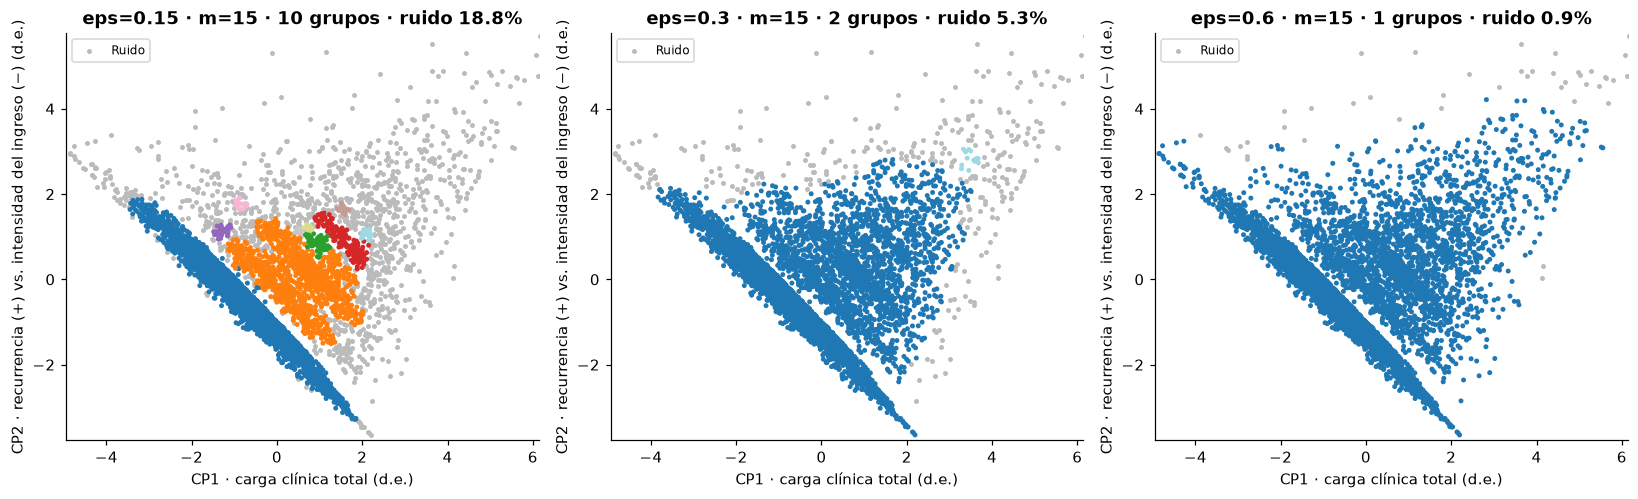

Completa         grupos=2  ruido=0.053
Mitad, m fijo    grupos=2  ruido=0.102
Mitad, m/2       grupos=4  ruido=0.042


In [14]:
CHOSEN_EPS, CHOSEN_M = 0.3, 15   # fijados con la tabla anterior (ver respuesta)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, eps in zip(axes, [CHOSEN_EPS / 2, CHOSEN_EPS, CHOSEN_EPS * 2]):
    lab = DBSCAN(eps=eps, min_samples=CHOSEN_M).fit_predict(X)
    ax.scatter(*X[lab == -1].T, s=5, color='#bbbbbb', label='Ruido')
    ax.scatter(*X[lab != -1].T, c=lab[lab != -1] % 20, cmap='tab20', s=5)
    plane_axes(ax, f'eps={eps:g} · m={CHOSEN_M} · {len(set(lab)) - (-1 in lab)} grupos · ruido {np.mean(lab == -1):.1%}')
    ax.legend(fontsize=8, loc='upper left')
fig.tight_layout(); plt.show()

db_labels = DBSCAN(eps=CHOSEN_EPS, min_samples=CHOSEN_M).fit_predict(X)
half = np.random.default_rng(SEED).choice(len(X), len(X) // 2, replace=False)
for name, pts, m in [('Completa', X, CHOSEN_M), ('Mitad, m fijo', X[half], CHOSEN_M), ('Mitad, m/2', X[half], max(2, CHOSEN_M // 2))]:
    lab = DBSCAN(eps=CHOSEN_EPS, min_samples=m).fit_predict(pts)
    print(f'{name:<16} grupos={len(set(lab) - {-1})}  ruido={np.mean(lab == -1):.3f}')

## 5. Refuerzo · K-means y jerárquico en los mismos 500 puntos
### Para resolver
K-means con datos 0, 1, 4, 5 y centros iniciales 0 y 4. Ward con A={0,2}, B={5}.

K-means manual → centros [0.5 4.5] inercia 1.0
Ward manual → altura SciPy 4.6188 = sqrt(2·Δ) con Δ = 10.6667


,k,inertia,silhouette
0,1,25049.623,NaN
1,2,16133.231,0.368
2,3,9348.543,0.426
3,4,7314.312,0.359
4,5,5558.579,0.396
5,6,4760.357,0.382
6,7,4025.249,0.401
7,8,3454.908,0.395


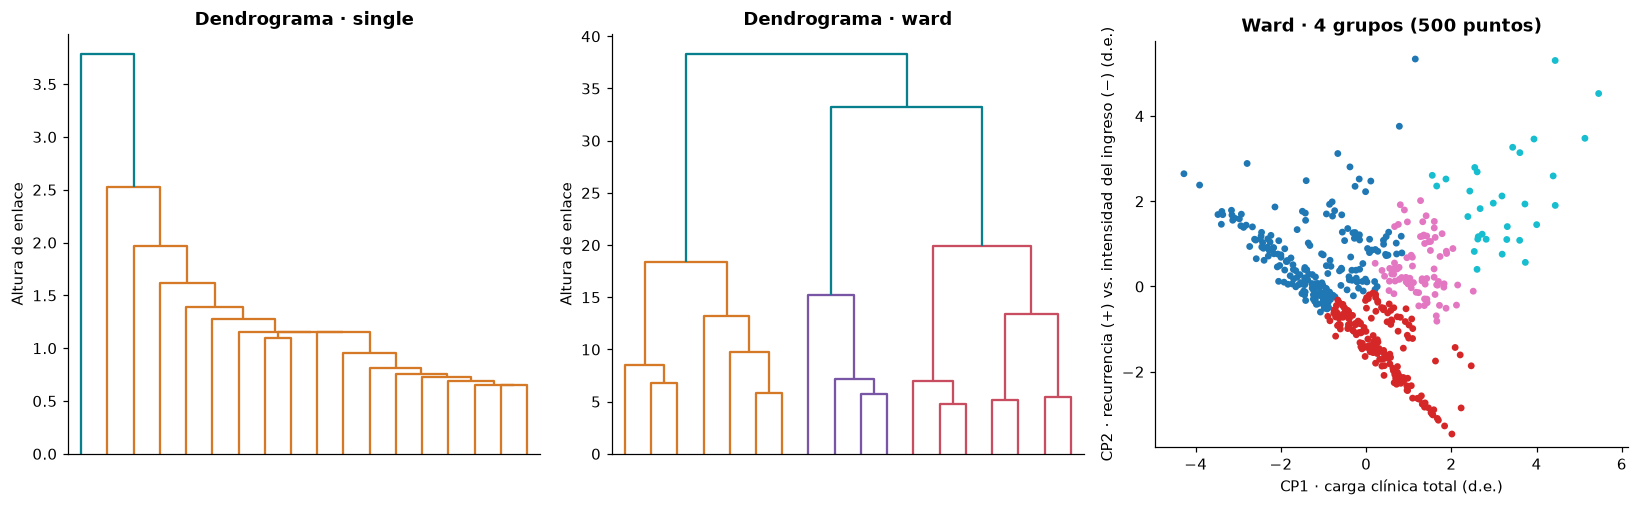

Mismos 500 puntos → silhouette K-means(4): 0.398 | Ward(4): 0.349


In [15]:
toy = KMeans(2, init=np.array([[0.], [4.]]), n_init=1).fit(np.array([0., 1., 4., 5.])[:, None])
print('K-means manual → centros', toy.cluster_centers_.ravel(), 'inercia', toy.inertia_)
ward_toy = linkage(np.array([0., 2., 5.])[:, None], method='ward')
print('Ward manual → altura SciPy', ward_toy[-1, 2].round(4), '= sqrt(2·Δ) con Δ =', (ward_toy[-1, 2] ** 2 / 2).round(4))

rows = []
for k in range(1, 9):
    km = KMeans(k, n_init=10, random_state=SEED).fit(X)
    rows.append(dict(k=k, inertia=km.inertia_, silhouette=safe_silhouette(X, km.labels_)))
km_tab = pd.DataFrame(rows); display(km_tab.round(3))

small_idx = np.random.default_rng(SEED).choice(len(X), 500, replace=False); Z = X[small_idx]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, method in zip(axes[:2], ['single', 'ward']):
    dendrogram(linkage(Z, method=method), truncate_mode='lastp', p=18, ax=ax, no_labels=True)
    ax.set(title=f'Dendrograma · {method}', ylabel='Altura de enlace')
tree = linkage(Z, method='ward')
ward4, km4 = fcluster(tree, t=4, criterion='maxclust'), KMeans(4, n_init=10, random_state=SEED).fit_predict(Z)
axes[2].scatter(*Z.T, c=ward4, cmap='tab10', s=12); plane_axes(axes[2], 'Ward · 4 grupos (500 puntos)')
fig.tight_layout(); plt.show()
print('Mismos 500 puntos → silhouette K-means(4):', round(safe_silhouette(Z, km4), 3), '| Ward(4):', round(safe_silhouette(Z, ward4), 3))

**Nuestra respuesta y evidencia:**


- **K-means manual:** centros 0.5 y 4.5, inercia **1.0**. **Ward manual:** Δ = 32/3 = 10.67; SciPy muestra √(2Δ) = 4.62.
- **K-means en pacientes agregados:** la inercia baja siempre (25 050 → 3 455); la silhouette (submuestra de 1 000) es máxima en K = 3 (0.426).
- **Jerárquico (500 puntos):** el enlace simple encadena a lo largo de la cresta; Ward produce grupos compactos. Misma submuestra: K-means(4) 0.398 vs. Ward(4) 0.349.

## 6. Evidencia comparada
### 6.1 Los tres mapas, mismos ejes

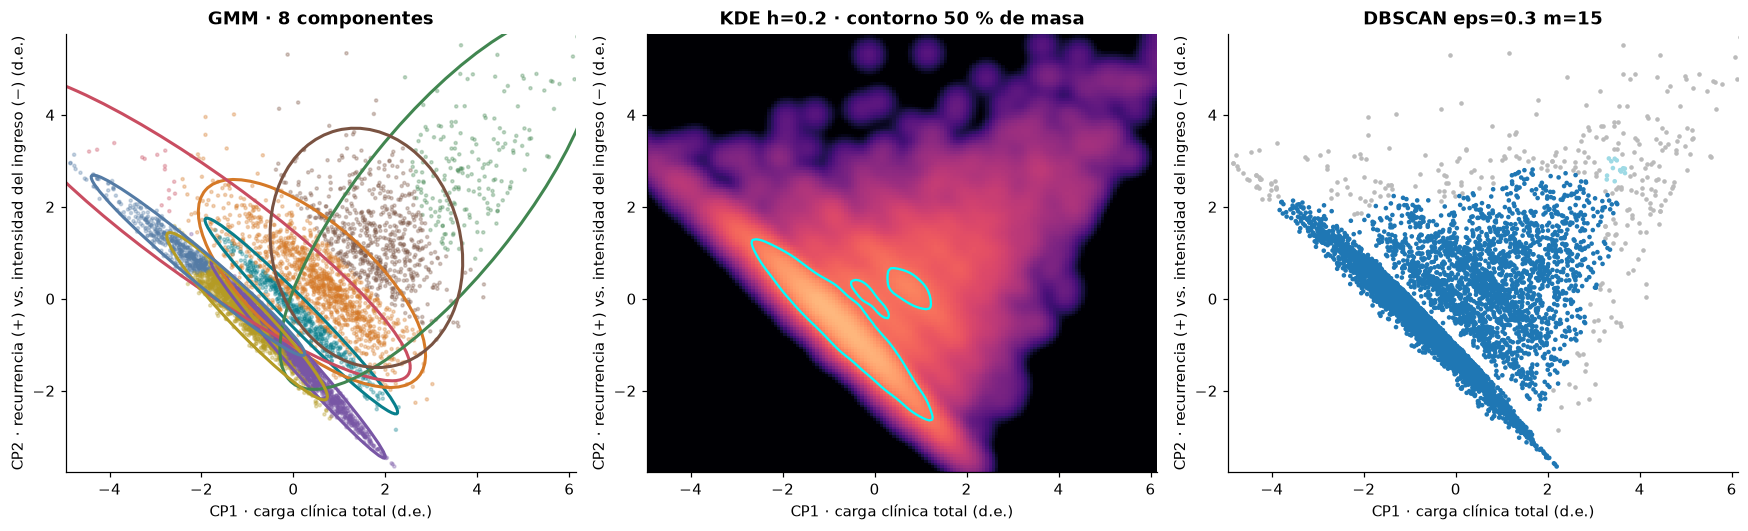

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(*X.T, c=np.asarray(COLORS)[best.predict(X) % 8], s=4, alpha=.3); ellipses(axes[0], best)
plane_axes(axes[0], f'GMM · {int(winner.k)} componentes')
axes[1].pcolormesh(xx, yy, np.log(dens + 1e-12), shading='auto', cmap='magma', vmin=-10, vmax=0)
axes[1].contour(xx, yy, dens, levels=[level50], colors='cyan', linewidths=1.5); plane_axes(axes[1], f'KDE h={best_h} · contorno 50 % de masa')
axes[2].scatter(*X[db_labels == -1].T, s=4, color='#bbbbbb')
axes[2].scatter(*X[db_labels != -1].T, c=db_labels[db_labels != -1] % 20, cmap='tab20', s=4)
plane_axes(axes[2], f'DBSCAN eps={CHOSEN_EPS} m={CHOSEN_M}')
fig.tight_layout(); plt.show()

### 6.2 Zonas candidatas descritas por rangos
Cada zona se define por **rangos del plano** (percentiles 5–95 de sus pacientes) y se traduce a variables clínicas (medianas).
La readmisión < 30 días se calcula **después** de congelar los modelos. Se reportan dos versiones: *en algún encuentro* (circular con
`n_encuentros`) y *en el primer encuentro* (menos circular, pero un paciente readmitido suele tener ≥ 2 encuentros; ver 1.1).

In [17]:
dev['gmm'] = best.predict(X); dev['dbscan'] = db_labels
dev['kde_logdens'] = kde.score_samples(X); dev['kde_top50'] = np.exp(dev.kde_logdens) >= level50
def describe(mask, name):
    sub = dev[mask]
    r = {'zona': name, 'n': len(sub), 'cobertura': len(sub) / len(dev),
         'CP1 (p5–p95)': f'[{sub.cp1.quantile(.05):.2f}, {sub.cp1.quantile(.95):.2f}]',
         'CP2 (p5–p95)': f'[{sub.cp2.quantile(.05):.2f}, {sub.cp2.quantile(.95):.2f}]'}
    r.update({c: sub[c].median() for c in FEATURES})
    r['% >1 encuentro'] = 100 * (sub.n_encuentros > 1).mean()
    r['readm<30 alguna (%)'] = 100 * sub.readm30_alguna.mean(); r['readm<30 primero (%)'] = 100 * sub.readm30_primero.mean()
    return r
rows = [describe(dev.gmm == k, f'GMM comp. {k}') for k in range(int(winner.k))]
rows += [describe(dev.dbscan == g, f'DBSCAN grupo {g}') for g in pd.Series(db_labels[db_labels != -1]).value_counts().index[:4]]
rows += [describe(dev.dbscan == -1, 'DBSCAN ruido'), describe(dev.kde_top50, 'KDE región 50 % masa'),
         describe(~dev.kde_top50, 'KDE fuera de 50 %'), describe(dev.index == dev.index, 'Todos')]
zones = pd.DataFrame(rows).set_index('zona'); display(zones.round(2))

,n,cobertura,CP1 (p5–p95),CP2 (p5–p95),n_encuentros,estancia_media,lab_medio,proc_medio,meds_medio,diag_medio,ambulat_max,urgenc_max,hosp_prev_max,edad,% >1 encuentro,readm<30 alguna (%),readm<30 primero (%)
zona,,,,,,,,,,,,,,,,,
GMM comp. 0,420,0.07,"[-1.06, 1.57]","[-1.83, 0.84]",1.0,4.00,46.75,1.25,15.00,8.0,0.0,0.0,0.0,65.0,23.81,7.38,6.90
GMM comp. 1,1314,0.22,"[-1.34, 2.00]","[-1.07, 1.82]",1.0,4.00,43.50,1.00,14.75,8.0,0.0,0.0,1.0,65.0,48.63,19.86,18.80
GMM comp. 2,1512,0.25,"[-1.07, 1.36]","[-2.74, 0.07]",1.0,5.00,50.00,1.00,18.00,9.0,0.0,0.0,0.0,75.0,0.00,5.49,5.49
GMM comp. 3,17,0.00,"[-6.00, -2.59]","[2.01, 4.13]",1.0,1.00,10.00,0.00,5.00,3.0,0.0,0.0,0.0,35.0,5.88,0.00,0.00
GMM comp. 4,205,0.03,"[2.74, 5.76]","[1.39, 5.23]",5.0,4.67,44.67,1.13,17.75,8.5,1.0,1.0,3.0,65.0,98.54,69.27,25.37
GMM comp. 5,1395,0.23,"[-1.90, -0.06]","[-1.46, 0.54]",1.0,3.00,41.00,1.00,12.00,5.0,0.0,0.0,0.0,65.0,0.00,2.80,2.80
GMM comp. 6,469,0.08,"[-4.02, -1.92]","[0.64, 2.39]",1.0,2.00,36.00,0.00,6.00,4.0,0.0,0.0,0.0,55.0,0.00,0.85,0.85
GMM comp. 7,668,0.11,"[0.48, 2.91]","[0.05, 2.88]",3.0,4.00,43.00,0.75,15.33,8.0,0.0,0.0,2.0,65.0,87.13,42.81,25.30
DBSCAN grupo 0,5665,0.94,"[-2.27, 2.11]","[-2.13, 1.70]",1.0,4.00,44.00,1.00,14.00,7.5,0.0,0.0,0.0,65.0,22.67,12.27,9.94


### 6.3 Tabla de sensibilidad consolidada (un hiperparámetro por método)
La silhouette de DBSCAN se estima, como en 4.1, sobre una submuestra fija de 1 000 puntos no-ruido.

In [18]:
sens = []
for cov in ['full', 'diag']:
    w = gmm_sel[(gmm_sel.covariance == cov) & gmm_sel.converged].sort_values('bic').iloc[0]
    sens.append(dict(método='GMM', variación=f'covarianza={cov}', resultado=f'K por BIC = {int(w.k)}'))
for h in [.1, best_h, 1.6]:
    ld = KernelDensity(bandwidth=h).fit(X).score_samples(G).reshape(xx.shape)
    d_ = np.exp(ld); o = np.sort(d_.ravel())[::-1]; lv = o[np.searchsorted(np.cumsum(o) * dx * dy, .5)]
    from scipy import ndimage
    nreg = ndimage.label(d_ >= lv)[1]
    sens.append(dict(método='KDE', variación=f'h={h:g}', resultado=f'{nreg} región(es) conexas con 50 % de masa; área {(d_ >= lv).mean():.1%} de la ventana'))
for eps in [CHOSEN_EPS / 2, CHOSEN_EPS, CHOSEN_EPS * 2]:
    lab = DBSCAN(eps=eps, min_samples=CHOSEN_M).fit_predict(X)
    sens.append(dict(método='DBSCAN', variación=f'eps={eps:g}, m={CHOSEN_M}',
                     resultado=f'{len(set(lab) - {-1})} grupos, cobertura {np.mean(lab != -1):.1%}, silhouette (1 000 pts) {safe_silhouette(X, lab):.3f}'))
sens = pd.DataFrame(sens); display(sens)

,método,variación,resultado
0,GMM,covarianza=full,K por BIC = 8
1,GMM,covarianza=diag,K por BIC = 10
2,KDE,h=0.1,8 región(es) conexas con 50 % de masa; área 3....
3,KDE,h=0.2,3 región(es) conexas con 50 % de masa; área 4....
4,KDE,h=1.6,1 región(es) conexas con 50 % de masa; área 17...
5,DBSCAN,"eps=0.15, m=15","10 grupos, cobertura 81.2%, silhouette (1 000 ..."
6,DBSCAN,"eps=0.3, m=15","2 grupos, cobertura 94.7%, silhouette (1 000 p..."
7,DBSCAN,"eps=0.6, m=15","1 grupos, cobertura 99.1%, silhouette (1 000 p..."


### 6.4 Evidencia por método


| Método | Objeto estimado | Parámetros elegidos (con desarrollo) | Evidencia | Limitación |
|---|---|---|---|---|
| **GMM** | Densidad como mezcla de 8 gaussianas + responsabilidades | K = 8, covarianza completa (mín. BIC; con diag el BIC llega al borde K = 10) | Separa la cresta de un solo encuentro (comp. 2, 5, 6, 3: 56 % de pacientes) de la transición (1: 22 %) y de los recurrentes (7: 11 %; 4: 3 %) | Necesita 4 elipses para una sola cresta; estabilidad baja (ARI 0.48) |
| **KDE** | Superficie de densidad (d.e.⁻²) | Gaussiano, h = 0.2 d.e. (validación temporal) | El 50 % de la masa ocupa el 4.3 % de la ventana y está sobre la cresta (solo el 6 % de esos pacientes tiene > 1 encuentro); el abanico es una meseta de baja densidad | Con h = 0.1 la región del 50 % se parte en 8 islas; con h = 1.6 es una loma única |
| **DBSCAN** | Componentes conectadas + ruido | eps = 0.3 d.e., m = 15 | 2 grupos: masa (94 %) y 15 pacientes muy recurrentes en CP1 ∈ [3.3, 3.7], CP2 ∈ [2.6, 3.1]; ruido 5.3 %, sobre todo en el abanico alto | Con eps = 0.15 separa cresta y abanico; con eps ≥ 0.6 todo es un grupo |

**Región que KDE suaviza y DBSCAN separa.** El borde entre la cresta y el abanico (aprox. CP1 ∈ [−1, 1.5], CP2 ∈ [−1.5, 1]): la KDE lo muestra como una
**caída continua** de densidad desde la cresta hacia el abanico. DBSCAN con eps = 0.15 **separa** la cresta (un grupo) del núcleo del abanico (otro grupo) y
varias islas; con eps = 0.3 los **conecta**. Aquí la separación de DBSCAN tiene sentido clínico —pacientes sin y con recurrencia—, pero depende de eps.


## 6.5 Extensión · Davies–Bouldin y estabilidad por remuestreo
La guía la propone para la semana siguiente; se adelanta aquí. **Davies–Bouldin** (menor es mejor) compara la dispersión de cada grupo con la
distancia a su grupo más parecido. La **estabilidad** se mide reajustando cada método en 20 remuestras bootstrap y comparando, con el
**índice de Rand ajustado (ARI)**, las etiquetas que la remuestra asigna a los 6 000 puntos con las de la solución original (1 = misma partición).
GMM y K-means asignan todos los puntos con `predict`; DBSCAN es transductivo, así que se compara solo sobre los puntos presentes en la remuestra.

In [19]:
from sklearn.metrics import davies_bouldin_score, adjusted_rand_score
km5 = KMeans(int(winner.k), n_init=10, random_state=SEED).fit(X)
ref = {'GMM (K=%d, full)' % int(winner.k): best.predict(X), 'K-means (K=%d)' % int(winner.k): km5.labels_,
       f'DBSCAN (eps={CHOSEN_EPS}, m={CHOSEN_M})': db_labels}
rng = np.random.default_rng(SEED); B = 20; stab = {k: [] for k in ref}
for b in range(B):
    ids = rng.choice(len(X), len(X), replace=True)
    g = GaussianMixture(int(winner.k), covariance_type=winner.covariance, n_init=2, max_iter=400,
                        reg_covar=1e-5, random_state=b).fit(X[ids])
    stab[list(ref)[0]].append(adjusted_rand_score(ref[list(ref)[0]], g.predict(X)))
    k_ = KMeans(int(winner.k), n_init=3, random_state=b).fit(X[ids])
    stab[list(ref)[1]].append(adjusted_rand_score(ref[list(ref)[1]], k_.predict(X)))
    u = np.unique(ids)
    stab[list(ref)[2]].append(adjusted_rand_score(db_labels[u], DBSCAN(eps=CHOSEN_EPS, min_samples=CHOSEN_M).fit_predict(X[u])))
rows = []
for name, lab in ref.items():
    m = lab != -1
    rows.append(dict(método=name, grupos=len(set(lab[m])), cobertura=m.mean(),
                     davies_bouldin=davies_bouldin_score(X[m], lab[m]) if len(set(lab[m])) > 1 else np.nan,
                     silhouette_1000=safe_silhouette(X, lab),
                     ARI_medio=np.mean(stab[name]), ARI_p10=np.percentile(stab[name], 10)))
ext = pd.DataFrame(rows); display(ext.round(3))

,método,grupos,cobertura,davies_bouldin,silhouette_1000,ARI_medio,ARI_p10
0,"GMM (K=8, full)",8,1.000,1.586,0.141,0.478,0.419
1,K-means (K=8),8,1.000,0.754,0.395,0.882,0.835
2,"DBSCAN (eps=0.3, m=15)",2,0.947,0.370,NaN,0.791,0.775


**Nuestra respuesta y evidencia:**


- **Davies–Bouldin:** DBSCAN 0.37, K-means 0.75, GMM 1.59. El valor de DBSCAN premia una separación trivial; GMM sale peor porque sus componentes se superponen a propósito.
- **Estabilidad (ARI, 20 remuestras bootstrap):** K-means **0.88** (p10 = 0.84), DBSCAN 0.79 (p10 = 0.78), GMM **0.48** (p10 = 0.42). Cambia respecto al cuaderno de
  primer encuentro: aquí K-means es estable (la cresta y el abanico le dan cortes claros) y el GMM de 8 componentes es **inestable**: las elipses que se
  pegan a lo largo de la cresta se reacomodan en cada remuestra. Refuerza que las 8 componentes son una aproximación, no perfiles.
- **Conclusión que permanece:** la división **cresta (un encuentro) / abanico (recurrentes)** aparece en los tres métodos, en K-means y en el remuestreo.

## 7. Congelar, después evaluar en el periodo reservado
Configuraciones congeladas con desarrollo. Ahora se abre el test (último 30 % de pacientes, en orden de su primer `encounter_id`) una sola vez.

In [20]:
frozen = dict(gmm=dict(k=int(winner.k), covariance=winner.covariance), kde_h=best_h, dbscan=dict(eps=CHOSEN_EPS, m=CHOSEN_M), seed=SEED)
print('Congelado:', frozen)
test['gmm_logdens'] = best.score_samples(Xt); test['kde_logdens'] = kde.score_samples(Xt)
test['block'] = pd.qcut(np.arange(len(test)), 4, labels=['T1', 'T2', 'T3', 'T4'])
display(test.groupby('block', observed=True)[['gmm_logdens', 'kde_logdens']].mean().round(3))
print('Media de desarrollo (in-sample) · GMM', best.score_samples(X).mean().round(3), '| KDE', kde.score_samples(X).mean().round(3))

test['gmm'] = best.predict(Xt); test['kde_top50'] = np.exp(test.kde_logdens) >= level50
comp_share = pd.DataFrame({'desarrollo': dev.gmm.value_counts(normalize=True), 'test': test.gmm.value_counts(normalize=True)}).sort_index()
display(comp_share.round(3))
display(test.groupby('gmm')[['readm30_alguna', 'readm30_primero']].mean().round(3))
print(f'Fracción en región KDE 50 %: desarrollo {dev.kde_top50.mean():.3f} | test {test.kde_top50.mean():.3f}')
# DBSCAN es transductivo: se reajusta con la misma configuración sobre una muestra de test del mismo tamaño.
lt = DBSCAN(eps=CHOSEN_EPS, min_samples=CHOSEN_M).fit_predict(Xt[np.random.default_rng(SEED).choice(len(Xt), 6000, replace=False)])
print(f'DBSCAN reajustado en 6 000 de test: {len(set(lt) - {-1})} grupos, cobertura {np.mean(lt != -1):.3f}')

Congelado: {'gmm': {'k': 8, 'covariance': 'full'}, 'kde_h': 0.2, 'dbscan': {'eps': 0.3, 'm': 15}, 'seed': 42}


,gmm_logdens,kde_logdens
block,,
T1,-2.811,-2.935
T2,-2.657,-2.794
T3,-2.587,-2.717
T4,-2.440,-2.587


Media de desarrollo (in-sample) · GMM -2.757 | KDE -2.846


,desarrollo,test
gmm,,
0,0.070,0.062
1,0.219,0.225
2,0.252,0.360
3,0.003,0.003
4,0.034,0.021
5,0.232,0.184
6,0.078,0.050
7,0.111,0.094


,readm30_alguna,readm30_primero
gmm,,
0,0.038,0.037
1,0.165,0.135
2,0.026,0.026
3,0.016,0.016
4,0.629,0.267
5,0.019,0.019
6,0.008,0.008
7,0.375,0.217


Fracción en región KDE 50 %: desarrollo 0.567 | test 0.607
DBSCAN reajustado en 6 000 de test: 2 grupos, cobertura 0.963


**Nuestra respuesta y evidencia:**


- **La densidad del test es *más alta* que la de desarrollo y sube de bloque en bloque** (GMM: −2.81, −2.66, −2.59, −2.44; desarrollo −2.76). No es que el modelo
  mejore: es la **censura**. Los pacientes que aparecen más tarde tienen menos encuentros, caen con más frecuencia en la cresta, que es la zona densa, y reciben
  densidades altas. Por la misma razón, la región KDE del 50 % pasa de contener el 56.7 % (desarrollo) al 60.7 % (test), y la componente 2 (cresta de un solo encuentro) pasa del 25 % al 36 %.
- DBSCAN reajustado en 6 000 pacientes de test: 2 grupos, cobertura 96.3 % (vs. 94.7 %): más pacientes en la masa principal, coherente con lo anterior.
- **Readmisión en test:** se mantiene el orden relativo (comp. 4: 63 %; comp. 7: 38 %; comp. 1: 17 %; cresta: 1–4 %), con la circularidad advertida.
- **Consecuencia práctica:** con historial agregado, la validación temporal no mide solo estabilidad del modelo sino también **cuánto historial alcanzó a
  acumularse**. Una evaluación justa exigiría igualar la ventana de observación (p. ej. contar solo los encuentros dentro de los N meses siguientes al primero), algo que la base no permite porque no tiene fechas.

## 7.1 ¿Qué cambia respecto al cuaderno de primer encuentro?

**Nuestra respuesta y evidencia:**


| Aspecto | Primer encuentro (`semana08_clustering_diabetes.ipynb`) | Historial agregado (este cuaderno) |
|---|---|---|
| Fila | Primer ingreso de cada paciente | Paciente con todos sus ingresos válidos |
| Pacientes | 69 970 | 69 987 (se incluyen pacientes cuyo primer ingreso no fue válido —p. ej. alta a hospicio— pero que tienen otros ingresos válidos) |
| Comportamiento longitudinal | Solo visitas previas **declaradas** en ese ingreso | Además, **cuántas veces volvió** dentro de la base |
| Forma del plano | Núcleo + abanico de uso previo | **Cresta** de pacientes de un solo encuentro + abanico de recurrentes |
| GMM (BIC) | K = 5 | K = 8 (varias elipses para una cresta), menos estable |
| KDE (h) | 0.4 d.e. | 0.2 d.e. (la cresta es estrecha) |
| DBSCAN (eps = 0.3, m = 15) | 2 grupos, 5.3 % ruido | 2 grupos, 5.3 % ruido |
| Readmisión como descripción externa | Independiente de los ejes (solo sesgada por la ventana) | **Circular** con `n_encuentros` |
| Test | Densidad estable | Densidad creciente por **censura** |

**Qué se gana:** se distingue a quien **volvió varias veces** de quien tuvo un único ingreso intenso, algo invisible con solo el primer encuentro, y sin
duplicar filas. **Qué se pierde:** la independencia entre el plano y la readmisión, y la comparabilidad temporal (censura). Ninguna versión domina a la otra:
responden preguntas distintas, y conviene presentarlas juntas.

## 8. Tickets individuales

**Nuestra respuesta y evidencia:**


**Lunes (GMM).** 1) EM maximiza la log-verosimilitud; puede quedar en un máximo local (aquí se ve: ARI 0.48 entre remuestras). 2) r = 0.55 es la fracción de la
densidad del modelo en ese punto aportada por una componente, no la probabilidad de pertenecer a un perfil real. 3) El BIC no demuestra un número verdadero de
grupos: aquí elige 8 porque la cresta no es gaussiana y necesita varias piezas.

**Miércoles (KDE).** Densidad puntual (altura), masa regional (proporción de pacientes en un área) y recursos (dependen del volumen absoluto, del riesgo, de la
capacidad y, aquí, de cuántos ingresos acumula cada paciente) son objetos distintos.

**Viernes (DBSCAN).** El diámetro de un grupo puede superar eps: la masa principal mide más de 6 d.e. con eps = 0.3. Un punto frontera no une grupos: solo los núcleos
expanden. Ruido no es error: el 5.3 % de ruido son pacientes muy recurrentes (44 % con readmisión en algún encuentro, 71 % con más de un encuentro), justamente los de mayor interés clínico.

## 9. Recomendación del comité

**Nuestra respuesta y evidencia:**


### Tres figuras interpretadas
1. **Figura 1 (GMM + entropía):** el GMM cubre la cresta con cuatro elipses alargadas y el abanico con otras cuatro; la entropía es alta en el borde entre ambos,
   donde la pertenencia es ambigua y la densidad baja.
2. **Figura 2 (KDE):** con h = 0.2 la cresta concentra la mitad de la masa en el 4 % del área; con h = 0.1 se fragmenta y con h = 1.6 desaparece. La cresta sobrevive a h razonables.
3. **Figura 3 (DBSCAN):** con eps = 0.15 separa cresta y abanico; con eps = 0.3 los une en una masa y deja como ruido a los pacientes más recurrentes; con eps = 0.6 todo es un grupo.

### Recomendación (Observo → interpreto → recomendaría estudiar → vigilaría → no puedo concluir)

> **Observo** que, al agregar todo el historial, los pacientes se ordenan en una cresta densa de quienes tuvieron **un solo encuentro** (75 % de la muestra; la
> KDE pone ahí la mitad de la masa en el 4 % del área) y un abanico disperso de **recurrentes**, que GMM divide en transición (22 %), recurrentes (11 %) y muy
> recurrentes (3 %), y que DBSCAN une a la masa o deja como ruido según eps. **Interpreto** que la recurrencia es el eje que más diferencia a los pacientes,
> pero su asociación con la readmisión es en parte **circular** (una readmisión es otro encuentro) y el periodo reservado está **censurado**. **Recomendaría
> estudiar** (A) la **zona de recurrentes**, CP1 ≈ 0.5 a 2.9 y CP2 ≈ 0 a 2.9 (componente 7: mediana de 3 encuentros y 2 hospitalizaciones previas, 11 % de los
> pacientes), y (B) la **transición**, CP1 ≈ −1.3 a 2.0 y CP2 ≈ −1.1 a 1.8 (componente 1: la mitad con un segundo encuentro, 22 %), que es donde un seguimiento
> podría actuar antes de que el paciente se vuelva recurrente. **Vigilaría** el extremo CP1 > 2.7, CP2 > 1.4 (componente 4 y el grupo de 15 pacientes de DBSCAN,
> ≈ 3 %, mediana de 5 encuentros), revisando caso a caso. **No puedo concluir** que la recurrencia *cause* readmisiones (la relación está construida), ni comparar
> sin sesgo desarrollo y test (censura), ni cuántos recursos se necesitan: faltan fechas, costos, capacidad y desenlaces fuera de la red.

### Guion de defensa (90 s)
- **20 s · Pregunta y datos:** 69 987 pacientes, una fila por paciente con todos sus encuentros; plano CP1 = carga clínica total, CP2 = recurrencia vs. intensidad.
- **40 s · Evidencia:** GMM K = 8 (varias elipses para una cresta, ARI 0.48); KDE h = 0.2 (50 % de la masa en el 4 % del área, sobre la cresta); DBSCAN eps = 0.3
  (masa + 15 muy recurrentes; con eps = 0.15 separa cresta y abanico). Los tres coinciden en **cresta vs. recurrentes**.
- **30 s · Recomendación y límites:** estudiar recurrentes y transición, vigilar muy recurrentes; readmisión circular con los ejes; test censurado.

## Fuentes y reproducción
- Guía `semana-08.html` y cuadernos de `semana-08-estudiantes (2)/notebooks/semana-08/` (estructura, utilidades y ejercicios manuales).
- Strack et al. (2014), *Impact of HbA1c measurement on hospital readmission rates*, BioMed Research International — fuente del dataset.
- scikit-learn: [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Cuaderno hermano: `semana08_clustering_diabetes.ipynb` (misma guía, solo el primer encuentro de cada paciente).
- Semilla 42 en todo el cuaderno; se ejecuta desde la raíz del repositorio (donde está `diabetic_data.csv`).